# Summary Graphs
Graphs of data across multiple years sampled weekly.

In [9]:
from IPython.display import display, Markdown
import snakemd
import datetime

from garmindb import GarminConnectConfigManager
from garmindb.garmindb import GarminSummaryDb, YearsSummary

from jupyter_funcs import format_number
from graphs import Graph

years_to_display = 1
days_to_display = (years_to_display * 365)

gc_config = GarminConnectConfigManager()
db_params_dict = gc_config.get_db_params()
garmin_sum_db = GarminSummaryDb(db_params_dict)

graph = Graph()

<YearsSummary() {'first_day': datetime.date(2024, 1, 1), 'hr_avg': None, 'hr_min': None, 'hr_max': None, 'rhr_avg': 59.0, 'rhr_min': 59.0, 'rhr_max': 59.0, 'inactive_hr_avg': None, 'inactive_hr_min': None, 'inactive_hr_max': None, 'weight_avg': None, 'weight_min': None, 'weight_max': None, 'intensity_time': datetime.time(0, 0), 'moderate_activity_time': datetime.time(0, 0), 'vigorous_activity_time': datetime.time(0, 0), 'intensity_time_goal': datetime.time(0, 0), 'steps': None, 'steps_goal': 6880, 'floors': 0.0, 'floors_goal': 10.0, 'sleep_avg': datetime.time(8, 13), 'sleep_min': datetime.time(8, 13), 'sleep_max': datetime.time(8, 13), 'rem_sleep_avg': datetime.time(1, 57), 'rem_sleep_min': datetime.time(1, 57), 'rem_sleep_max': datetime.time(1, 57), 'stress_avg': None, 'calories_avg': 3842, 'calories_bmr_avg': 2328, 'calories_active_avg': 0, 'calories_goal': None, 'calories_consumed_avg': None, 'activities': 30, 'activities_calories': 16612, 'activities_distance': 99.657737564896, 'hy

### Heart Rate

| Year | Avg Resting HR | Min Resting HR | Max Resting HR | Avg HR | Min HR | Max HR |
| ---- | -------------- | -------------- | -------------- | ------ | ------ | ------ |
| 2024 | 59.0           | 59.0           | 59.0           | -      | -      | -      |
| 2025 | 55.0           | 49.0           | 63.0           | 74.0   | 39.0   | 201.0  |

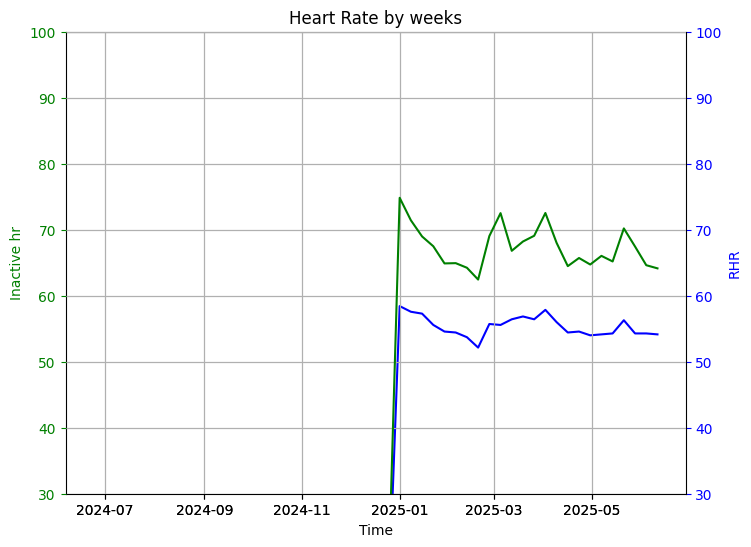

In [10]:
years_data = []
current_year = datetime.date.today().year
for year in range(current_year - years_to_display, current_year + 1):
    year_data = YearsSummary.get_year(garmin_sum_db, year)
    print(year_data)
    years_data.append([year, format_number(year_data.rhr_avg), format_number(year_data.rhr_min), format_number(year_data.rhr_max),
                       format_number(year_data.hr_avg), format_number(year_data.hr_min), format_number(year_data.hr_max)])

doc = snakemd.new_doc()
doc.add_heading("Heart Rate", 3)
doc.add_table(['Year', 'Avg Resting HR', 'Min Resting HR', 'Max Resting HR', 'Avg HR', 'Min HR', 'Max HR'], years_data)
display(Markdown(str(doc)))
graph.graph_activity('hr', days=days_to_display)

### Intensity Minutes

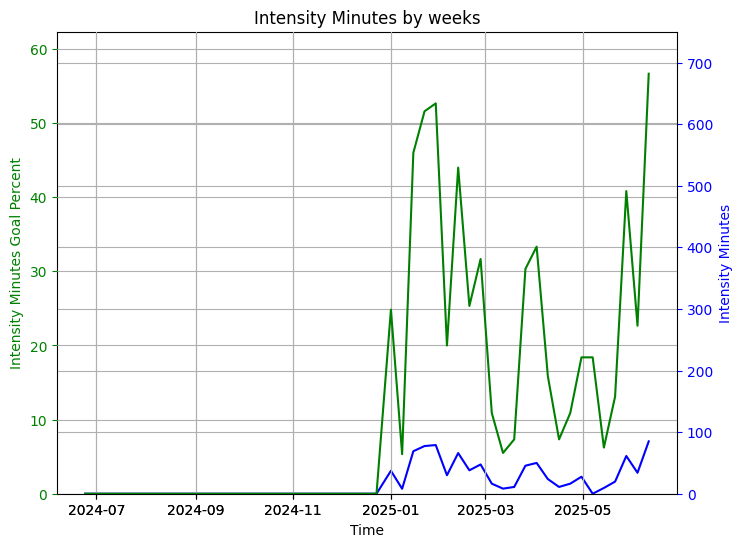

In [11]:
graph.graph_activity('itime', days=days_to_display)

In [ ]:
years_data = []
current_year = datetime.date.today().year
for year in range(current_year - years_to_display, current_year + 1):
    year_data = YearsSummary.get_year(garmin_sum_db, year)
    years_data.append([year, year_data.steps, year_data.steps_goal, format_number((year_data.steps_goal / year_data.steps) * 100.0)])

doc = snakemd.new_doc()
doc.add_heading("Steps", 3)
doc.add_table(['Year', 'Steps', 'Steps Goal', 'Steps Goal %'], years_data)
display(Markdown(str(doc)))
graph.graph_activity('steps')

TypeError: unsupported operand type(s) for /: 'int' and 'NoneType'

In [ ]:
years_data = []
current_year = datetime.date.today().year
for year in range(current_year - years_to_display, current_year + 1):
    year_data = YearsSummary.get_year(garmin_sum_db, year)
    years_data.append([year, format_number(year_data.weight_avg), format_number(year_data.weight_min), format_number(year_data.weight_max)])

doc = snakemd.new_doc()
doc.add_heading("Weight", 3)
doc.add_table(['Year', 'Avg Weight', 'Min Weight', 'Max Weight'], years_data)
display(Markdown(str(doc)))
graph.graph_activity('weight', days=days_to_display)